### Components of time series  

**Introduction:** 

The four components of time series, we will consider here, are the trend, seasonality, offset, and noise (white/colored). The observation equation of a time series with these four components is represented by:

$$
Y(t) = y_0 + r t + \underbrace{ a \cos(2\pi f_1t) + b\sin(2\pi f_1t)}_{A \cos(2\pi f_1 t+\theta)} + o {u_k(t)} + \epsilon(t)
$$

where
- $y_0 $: intercept (e.g. in mm).
- $r$: is the rate (e.g. in mm/year).
- $a$ and $b$ are the coefficients of the periodic signal.
- $f_1$ is the frequency of the seasonal component (e.g. 1 cycle/year).
- $o$ is the size of the offset at time instant $t_k$.
- $u_k(t)$ is the unit step function which is 1 if $t_k \leq t$ and 0 otherwise.
- $\epsilon(t)$ is the random noise with a given variance which follows a Normal distribution: $ \epsilon(t) \sim N(0, \sigma_{\epsilon}^2)$.

Here, we assume there is only a single seasonality and offset component. However, in many practical scenarios, there could be multiple components related to these.

**Exercise:**

In this exercise we will create a time series containing the four components previously discribed. At each step we will add a new component to the time series. You can copy and use the code provided below to change the input variables and see how the plots of the genereated time series changes.

*The noise follows a normal distribution: use np.random.normal in order to draw random samples from a normal (Gaussian) distribution. Study more on this function [here](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)*.

We will first create the time series $Y(t)=y_0+rt$, with $y_0=1$ mm and $r=0.02$ mm/day with a duration of 500 days (i.e., time series consists of 500 observations).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

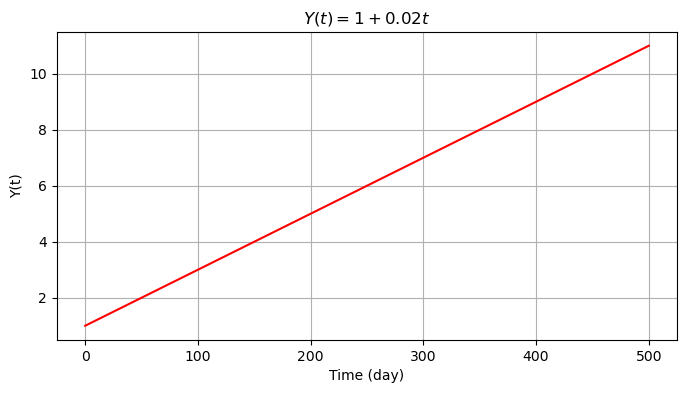

In [3]:
np.random.seed(0)  # For reproducibility

time = np.arange(501) 
m = len(time)
y_0 = 1 
r = 0.02 
y1 = y_0 + r*time 

plt.figure(figsize=(8,4))
plt.grid()
plt.plot(time, y1, color='red')
plt.ylabel('Y(t)')
plt.xlabel('Time (day)')
plt.title('$Y(t) = 1 + 0.02 t $');

We then introduce seasonality to the data with a cosine signal $s(t)=A \cos(2\pi f_1 t + \theta)$ with frequency $f_1=0.01$ cycle/day (i.e., 1 cycle per 100 days), amplitude $A=1$ mm and initial phase $\theta=0.2\pi$ rad.

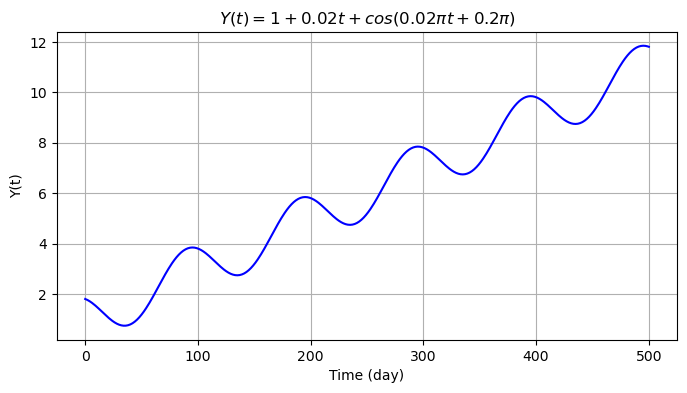

In [ ]:
f_1 = 0.01
A = 1 
theta = 0.2*np.pi 
y2 = y1 + A*np.cos(2 * np.pi*f_1 * time + theta) 

plt.figure(figsize=(8,4))
plt.grid()
plt.plot(time, y2, color='blue')
plt.ylabel('Y(t)')
plt.xlabel('Time (day)')
plt.title('$Y(t) = 1 + 0.02 t + cos(0.02πt + 0.2π)$');

We now add an offset $o_k=5$ at $t=300$ days. We therefore create a copy of the previous signal and store it into a new array.

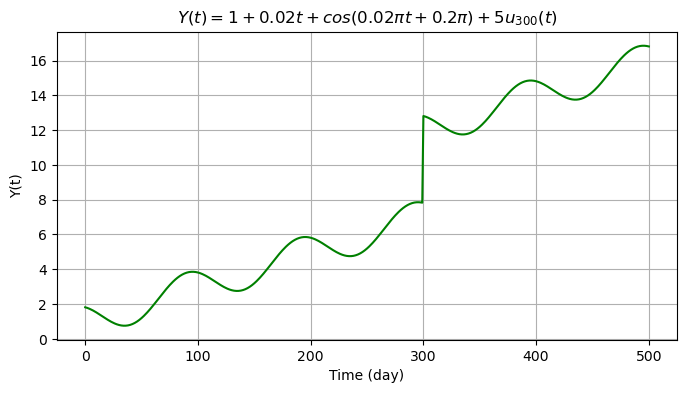

In [5]:
t_k = 300 
O_k = 5 
y3 = y2.copy() 
y3[t_k:] = y3[t_k:] + O_k

plt.figure(figsize=(8,4))
plt.grid()
plt.plot(time, y3, color='g')
plt.ylabel('Y(t)')
plt.xlabel('Time (day)')
plt.title('$Y(t) = 1 + 0.02 t + cos(0.02πt + 0.2π) + 5 u_{300}(t)$');

Eventually we include the random error $\epsilon \sim N(\mu, \sigma^2_{\epsilon})$ with $\mu=0$ mm and $\sigma_{\epsilon}=0.5$ mm. 

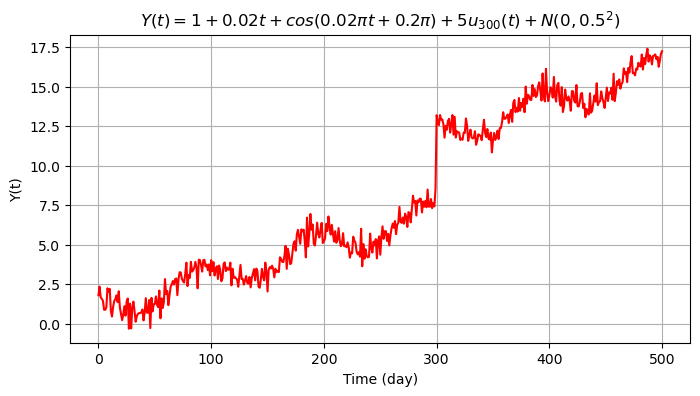

In [7]:
mean = 0 
sigma = 0.5 
et = np.random.normal(loc = mean, scale = sigma, size = m) 
y4 = y3 + et 

plt.figure(figsize=(8,4))
plt.grid()
plt.plot(time, y4, color='red')
plt.ylabel('Y(t)')
plt.xlabel('Time (day)')
plt.title('$Y(t) = 1 + 0.02 t + cos(0.02πt + 0.2π) + 5 u_{300}(t) + N(0,0.5^2)$');